In [1]:
## Investment Behaviour Analysis

In [2]:
#Import Required Libraries

In [3]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
#reading csv file
url ="https://raw.githubusercontent.com/pratiksha798/Cognifyz-Internship-Investment-Behavior-Analysis-Dashboard/refs/heads/main/Data_set%202.csv"
df = pd.read_csv(url)

In [5]:
df.head(10)

,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,...,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,...,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,...,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,...,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,...,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet
5,Female,24,No,7,5,4,6,3,1,2,...,1-3 years,Daily,30%-40%,Mutual Fund,Retirement Plan,Liquidity,Fund Diversification,Safe Investment,Risk Free,Internet
6,Female,27,Yes,3,6,4,2,5,1,7,...,3-5 years,Monthly,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,High Interest Rates,Financial Consultants
7,Male,21,Yes,2,3,7,4,6,1,5,...,3-5 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Assured Returns,Risk Free,Newspapers and Magazines
8,Male,35,Yes,2,4,7,5,3,1,6,...,1-3 years,Weekly,20%-30%,Equity,Retirement Plan,Capital Appreciation,Fund Diversification,Safe Investment,Fixed Returns,Television
9,Male,31,Yes,1,3,7,4,5,2,6,...,3-5 years,Monthly,30%-40%,Fixed Deposits,Retirement Plan,Capital Appreciation,Fund Diversification,Assured Returns,Fixed Returns,Newspapers and Magazines


In [6]:
df.shape

(40, 24)

In [7]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             40 non-null     object
 1   age                                40 non-null     int64 
 2   Investment_Avenues                 40 non-null     object
 3   Mutual_Funds                       40 non-null     int64 
 4   Equity_Market                      40 non-null     int64 
 5   Debentures                         40 non-null     int64 
 6   Government_Bonds                   40 non-null     int64 
 7   Fixed_Deposits                     40 non-null     int64 
 8   PPF                                40 non-null     int64 
 9   Gold                               40 non-null     int64 
 10  Stock_Marktet                      40 non-null     object
 11  Factor                             40 non-null     object
 12  Objective 

In [8]:
# Check missing values
df.isnull().sum()

gender                               0
age                                  0
Investment_Avenues                   0
Mutual_Funds                         0
Equity_Market                        0
Debentures                           0
Government_Bonds                     0
Fixed_Deposits                       0
PPF                                  0
Gold                                 0
Stock_Marktet                        0
Factor                               0
Objective                            0
Purpose                              0
Duration                             0
Invest_Monitor                       0
Expect                               0
Avenue                               0
What are your savings objectives?    0
Reason_Equity                        0
Reason_Mutual                        0
Reason_Bonds                         0
Reason_FD                            0
Source                               0
dtype: int64

In [9]:
# There are no missing values in our dataset. 

In [10]:
# Data Cleaning

In [11]:
## Let us seperate the numerical and object datatypes:
object_datatype=[]

for i in df.dtypes.index:
    if df.dtypes[i] == 'object':
        object_datatype.append(i)
object_datatype

['gender',
 'Investment_Avenues',
 'Stock_Marktet',
 'Factor',
 'Objective',
 'Purpose',
 'Duration',
 'Invest_Monitor',
 'Expect',
 'Avenue',
 'What are your savings objectives?',
 'Reason_Equity',
 'Reason_Mutual',
 'Reason_Bonds',
 'Reason_FD',
 'Source']

In [12]:
numerical_datatype=[]

for i in df.dtypes.index:
    if df.dtypes[i] != 'object':
        numerical_datatype.append(i)
numerical_datatype

['age',
 'Mutual_Funds',
 'Equity_Market',
 'Debentures',
 'Government_Bonds',
 'Fixed_Deposits',
 'PPF',
 'Gold']

<Axes: >

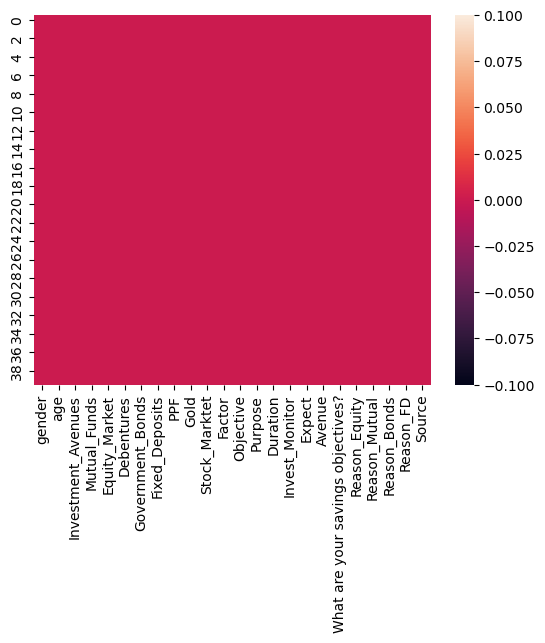

In [13]:
# Let us visualize the null values using heatmap:
sns.heatmap(df.isnull())

In [14]:
df.duplicated().sum()

0

In [15]:
df.nunique()

gender                                2
age                                  14
Investment_Avenues                    2
Mutual_Funds                          6
Equity_Market                         6
Debentures                            7
Government_Bonds                      7
Fixed_Deposits                        7
PPF                                   6
Gold                                  6
Stock_Marktet                         2
Factor                                3
Objective                             3
Purpose                               3
Duration                              4
Invest_Monitor                        3
Expect                                3
Avenue                                4
What are your savings objectives?     3
Reason_Equity                         3
Reason_Mutual                         3
Reason_Bonds                          3
Reason_FD                             3
Source                                4
dtype: int64

In [16]:
# Exploratory Data Analysis (EDA)

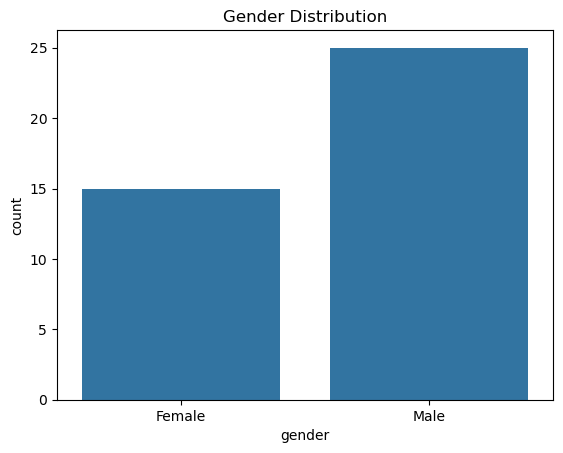

In [17]:
#Gender Distribution
df['gender'].value_counts()
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

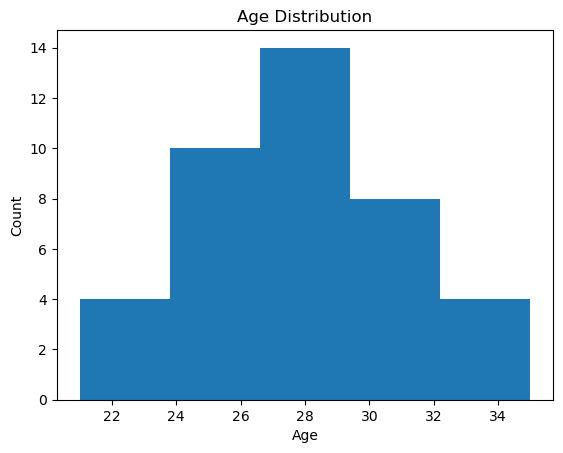

In [18]:
# Age Distribution
plt.hist(df['age'], bins=5)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

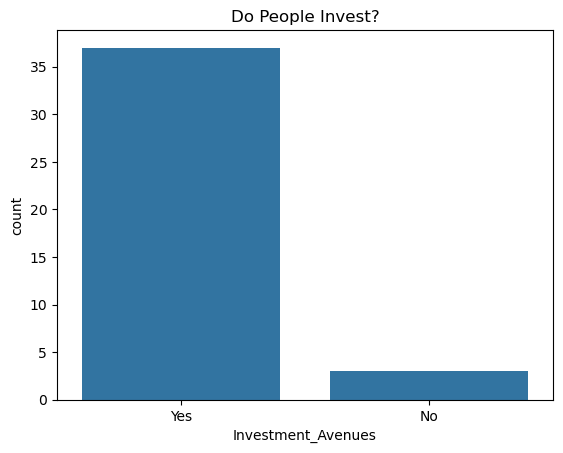

In [19]:
# Investment Avenue Preference
sns.countplot(x='Investment_Avenues', data=df)
plt.title("Do People Invest?")
plt.show()

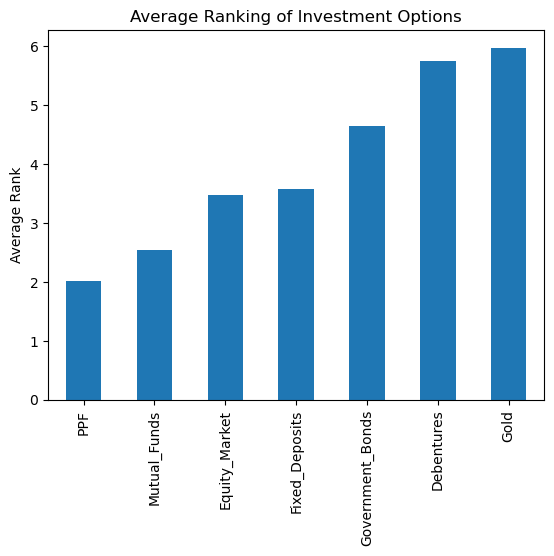

In [20]:
# Most Preferred Investment Option
investment_cols = ['Mutual_Funds','Equity_Market','Debentures',
                   'Government_Bonds','Fixed_Deposits','PPF','Gold']

df[investment_cols].mean().sort_values().plot(kind='bar')
plt.title("Average Ranking of Investment Options")
plt.ylabel("Average Rank")
plt.show()

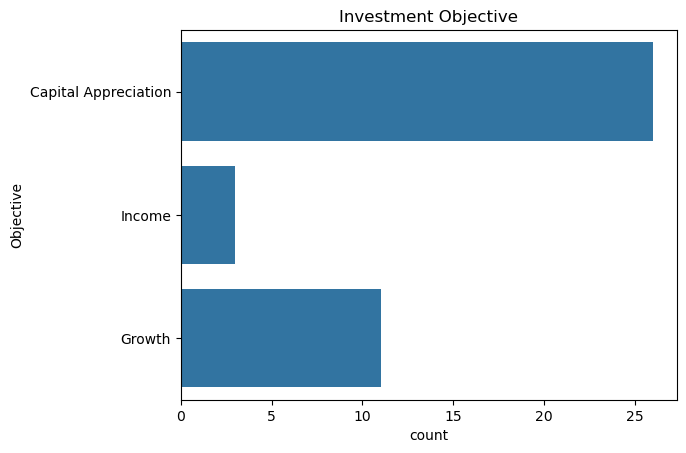

In [21]:
# Investment Objective
sns.countplot(y='Objective', data=df)
plt.title("Investment Objective")
plt.show()

In [22]:
## Correlation Analysis

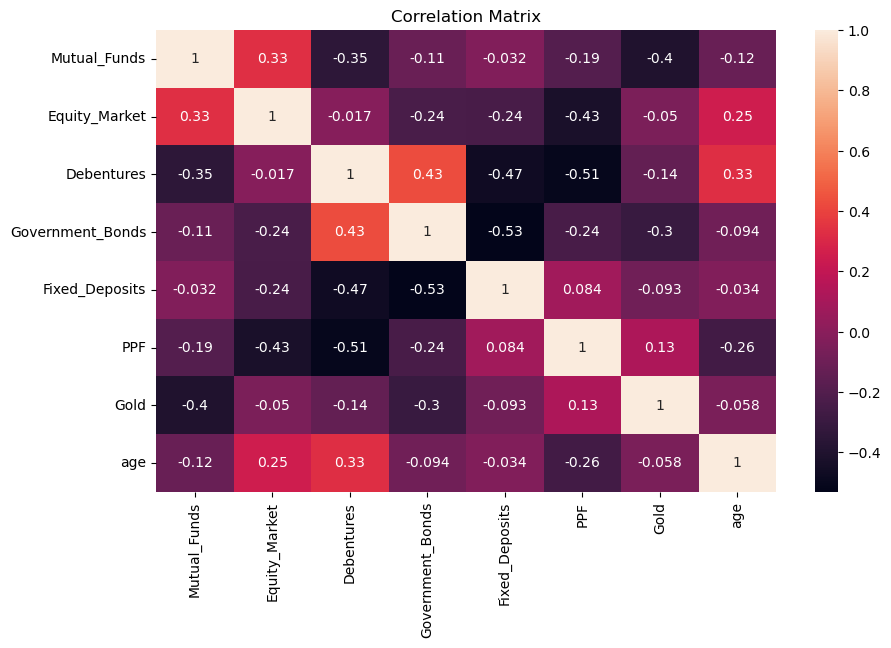

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df[investment_cols + ['age']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

In [24]:
## Feature Engineering for ML

# We’ll build a model to predict:

#Target Variable: Investment_Avenues (Yes/No)

In [25]:
# Encode Categorical Variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [26]:
# Define Features & Target
X = df.drop("Investment_Avenues", axis=1)
y = df["Investment_Avenues"]

In [27]:
## Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
## Build Machine Learning Model

In [30]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
# Model Prediction

In [32]:
y_pred = model.predict(X_test)

In [33]:
# Model Evaluation

In [34]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.75


In [35]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.75      1.00      0.86         6

    accuracy                           0.75         8
   macro avg       0.38      0.50      0.43         8
weighted avg       0.56      0.75      0.64         8



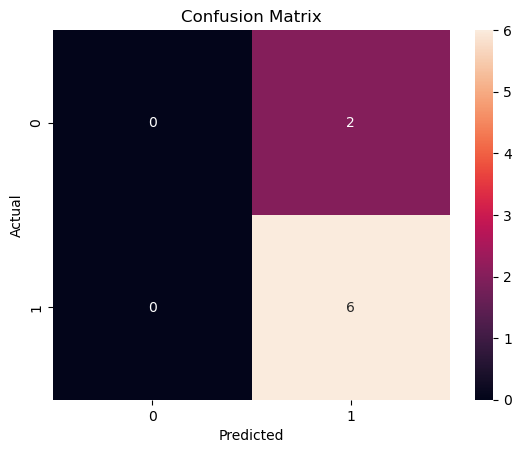

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
## Feature Importance

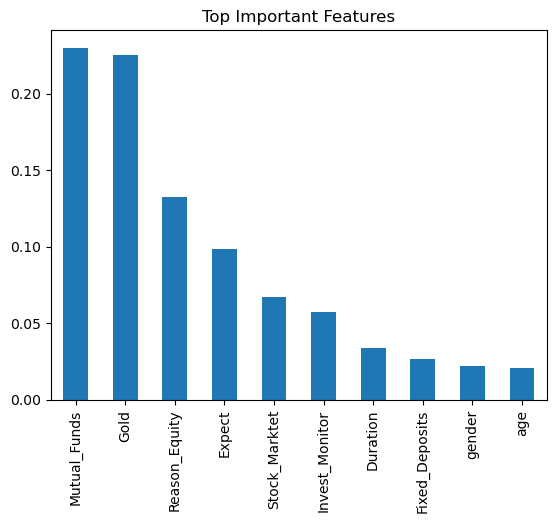

In [38]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()

In [39]:
## Key Insights

#Most respondents prefer Mutual Funds and Equity.
#Capital Appreciation is the major reason for Equity investment.
#Majority invest for Retirement Planning.
#Financial Consultants are major sources of information.
#Random Forest achieved 75% accuracy in predicting investment behavior.

In [40]:
# Save Model Using Joblib

In [41]:
import joblib

In [42]:
from sklearn.ensemble import RandomForestClassifier 
model = RandomForestClassifier()  
model.fit(X_train, y_train)  

# Now save the model
joblib.dump(model, "investment_model.pkl")

['investment_model.pkl']